In [1]:
from pathlib import Path

import pandas as pd

rootPath = Path().cwd().parent.parent

power_plants_data_path = rootPath.joinpath("data", "power_plants", "global_power_plant_database.csv")
power_plants_data = pd.read_csv(power_plants_data_path, low_memory=False)
power_plants_data.head()


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [2]:
AFRICAN_COUNTRIES = (
    "Algeria",
    "Angola",
    "Benin",
    "Botswana",
    "Burkina Faso",
    "Burundi",
    "Cameroon",
    "Cape Verde",
    "Central African Republic",
    "Congo",
    "Cote DIvoire",
    "Democratic Republic of the Congo",
    "Djibouti",
    "Egypt",
    "Equatorial Guinea",
    "Eritrea",
    "Ethiopia",
    "Gabon",
    "Gambia",
    "Ghana",
    "Guinea",
    "Guinea-Bissau",
    "Kenya",
    "Lesotho",
    "Liberia",
    "Libya",
    "Madagascar",
    "Malawi",
    "Mali",
    "Mauritania",
    "Mauritius",
    "Morocco",
    "Mozambique",
    "Namibia",
    "Niger",
    "Nigeria",
    "Rwanda",
    "Senegal",
    "Sierra Leone",
    "South Africa",
    "Sudan",
    "Swaziland",
    "Tanzania",
    "Togo",
    "Tunisia",
    "Uganda",
    "Western Sahara",
    "Zambia",
    "Zimbabwe",
)

In [3]:
african_power_plants = power_plants_data.query(
    "country_long in @AFRICAN_COUNTRIES"
)
african_power_plants.to_csv(power_plants_data_path.parent / "african_power_plants.csv", index=False)

african_power_plants.head()

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
17,DZA,Algeria,Adrar,WKS0068905,20.0,27.9080,-0.3170,Solar,NaN,NaN,...,NaN,35.22,34.22,35.33,35.17,NO-ESTIMATION,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
18,DZA,Algeria,Ain Azel,WKS0065285,20.0,35.8800,5.4750,Solar,NaN,NaN,...,NaN,38.68,37.56,38.37,38.75,NO-ESTIMATION,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
19,DZA,Algeria,Ain Djasser,WRI1023776,520.0,35.8665,6.0262,Gas,Oil,NaN,...,NaN,NaN,NaN,NaN,2171.28,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1
20,DZA,Algeria,Ain Sekhouna,WKS0068919,20.0,34.5320,0.8040,Solar,NaN,NaN,...,NaN,34.85,33.67,34.54,35.46,NO-ESTIMATION,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
21,DZA,Algeria,Ain el Ibel I,WKS0068916,20.0,34.3460,3.1640,Solar,NaN,NaN,...,NaN,33.42,33.58,34.75,34.81,NO-ESTIMATION,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE


In [4]:
power_plants = african_power_plants

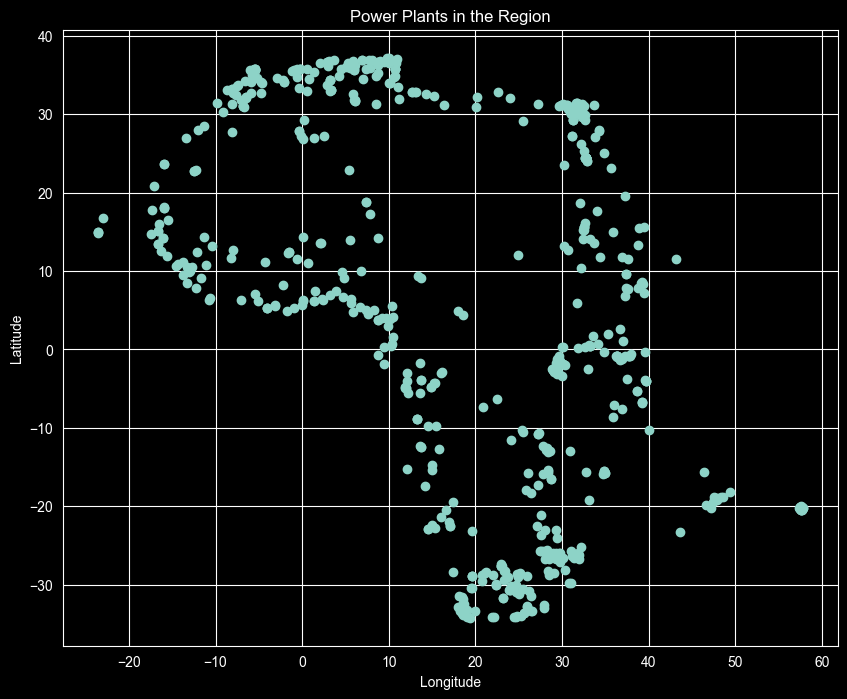

In [5]:
import matplotlib.pyplot as plt

# Plot longitude on X, latitude on Y
plt.figure(figsize=(10, 8))
plt.scatter(power_plants['longitude'], power_plants['latitude'])
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Power Plants in the Region')
plt.show()

In [6]:
import geopandas as gpd
from shapely.geometry import Point

# Create Point objects from lat/lon
geometry = [Point(lon, lat) for lon, lat in
            zip(power_plants['longitude'], power_plants['latitude'])]

# Convert to GeoDataFrame
power_plants_gdf = gpd.GeoDataFrame(
    power_plants,
    geometry=geometry,
    crs="EPSG:4326"  # This tells GeoPandas we're using standard lat/lon
)

power_plants_gdf.head()

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017,geometry
17,DZA,Algeria,Adrar,WKS0068905,20.0,27.9080,-0.3170,Solar,NaN,NaN,...,35.22,34.22,35.33,35.17,NO-ESTIMATION,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,POINT (-0.317 27.908)
18,DZA,Algeria,Ain Azel,WKS0065285,20.0,35.8800,5.4750,Solar,NaN,NaN,...,38.68,37.56,38.37,38.75,NO-ESTIMATION,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,POINT (5.475 35.88)
19,DZA,Algeria,Ain Djasser,WRI1023776,520.0,35.8665,6.0262,Gas,Oil,NaN,...,NaN,NaN,NaN,2171.28,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (6.0262 35.8665)
20,DZA,Algeria,Ain Sekhouna,WKS0068919,20.0,34.5320,0.8040,Solar,NaN,NaN,...,34.85,33.67,34.54,35.46,NO-ESTIMATION,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,POINT (0.804 34.532)
21,DZA,Algeria,Ain el Ibel I,WKS0068916,20.0,34.3460,3.1640,Solar,NaN,NaN,...,33.42,33.58,34.75,34.81,NO-ESTIMATION,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,POINT (3.164 34.346)


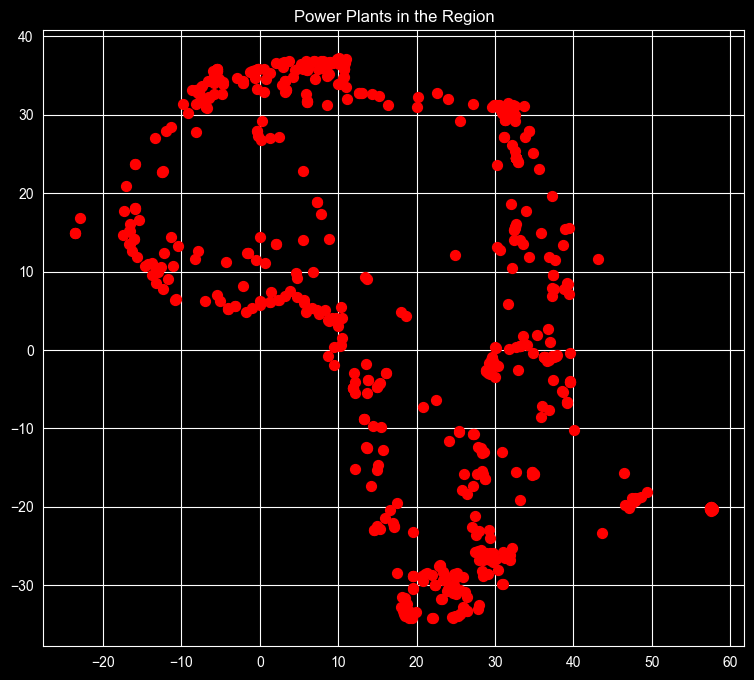

In [7]:
power_plants_gdf.plot(figsize=(10, 8), marker='o', color='red', markersize=50)
plt.title('Power Plants in the Region')
plt.show()

,featurecla,scalerank,labelrank,sovereignt,sov_a3,adm0_dif,level,type,tlc,admin,...,fclass_id,fclass_pl,fclass_gr,fclass_it,fclass_nl,fclass_se,fclass_bd,fclass_ua,filename,geometry
0,Admin-0 country,1,2,Ethiopia,ETH,0,2,Sovereign country,1,Ethiopia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ETH.geojson,"POLYGON ((47.78942 8.003, 44.9636 5.00162, 43...."
1,Admin-0 country,1,3,South Sudan,SDS,0,2,Sovereign country,1,South Sudan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SSD.geojson,"POLYGON ((30.83385 3.50917, 29.9535 4.1737, 29..."
2,Admin-0 country,1,6,Somalia,SOM,0,2,Sovereign country,1,Somalia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOM.geojson,"POLYGON ((41.58513 -1.68325, 40.993 -0.85829, ..."
3,Admin-0 country,1,2,Kenya,KEN,0,2,Sovereign country,1,Kenya,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,KEN.geojson,"POLYGON ((39.20222 -4.67677, 37.7669 -3.67712,..."
4,Admin-0 country,1,6,Malawi,MWI,0,2,Sovereign country,1,Malawi,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MWI.geojson,"POLYGON ((32.75938 -9.2306, 33.73972 -9.41715,..."


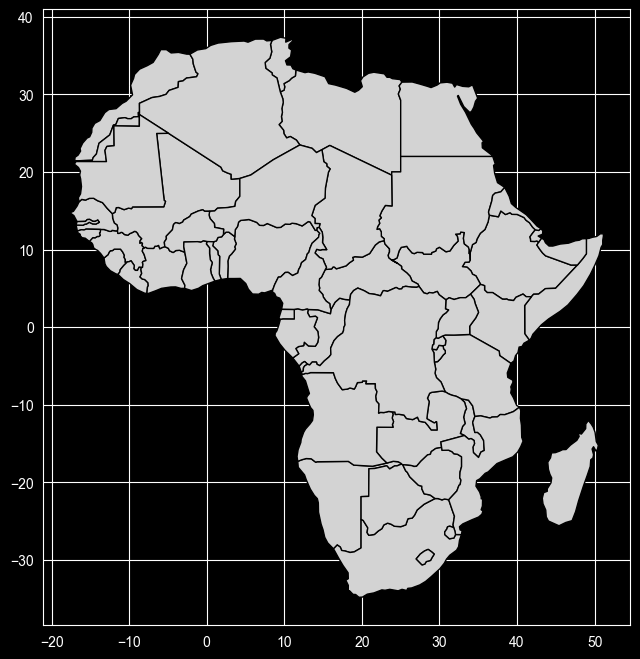

In [8]:
countries = gpd.read_file(rootPath / "data" / "geo" / "africa" / "africa.geo.json")
countries.plot(figsize=(10, 8), color='lightgray', edgecolor='black')
countries.head()


In [9]:
power_plants_tagged = gpd.sjoin(
    power_plants_gdf,      # Left: the data we want to tag
    countries,         # Right: the polygons with labels we want
    how="left",        # Keep all power plants, even if no match
    predicate="within" # The spatial relationship to test
)

In [10]:
print(countries.shape)
print(power_plants_gdf.shape)
print(power_plants_tagged.shape)


(51, 170)
(631, 37)
(631, 207)


In [11]:
power_plants_tagged.head(10)

,country,country_long,name_left,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,fclass_tr,fclass_id,fclass_pl,fclass_gr,fclass_it,fclass_nl,fclass_se,fclass_bd,fclass_ua,filename
17,DZA,Algeria,Adrar,WKS0068905,20.0,27.9080,-0.3170,Solar,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DZA.geojson
18,DZA,Algeria,Ain Azel,WKS0065285,20.0,35.8800,5.4750,Solar,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DZA.geojson
19,DZA,Algeria,Ain Djasser,WRI1023776,520.0,35.8665,6.0262,Gas,Oil,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DZA.geojson
20,DZA,Algeria,Ain Sekhouna,WKS0068919,20.0,34.5320,0.8040,Solar,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DZA.geojson
21,DZA,Algeria,Ain el Ibel I,WKS0068916,20.0,34.3460,3.1640,Solar,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DZA.geojson
22,DZA,Algeria,Ain el Ibel II,WKS0073479,53.0,34.3420,3.1690,Solar,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DZA.geojson
23,DZA,Algeria,Ain el Melh,WKS0068915,20.0,34.8610,4.2040,Solar,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DZA.geojson
24,DZA,Algeria,Algerie Sud-Ouest,WKS0068912,43.5,27.9080,-0.3170,Solar,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DZA.geojson
25,DZA,Algeria,Annaba,WRI1023795,71.0,36.8924,7.7634,Gas,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,DZA,Algeria,Aoulef,WKS0068908,5.0,26.9989,1.3351,Solar,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DZA.geojson


In [12]:
fuel_by_country = power_plants_tagged.groupby(['name_long', 'primary_fuel']).size().unstack(fill_value=0)
fuel_by_country.loc[['Zambia', 'Malawi']]

primary_fuel,Biomass,Coal,Gas,Geothermal,Hydro,Nuclear,Oil,Solar,Waste,Wind
name_long,,,,,,,,,,
Zambia,1,1,0,0,3,0,7,1,0,0
Malawi,1,0,1,0,3,0,0,0,0,0


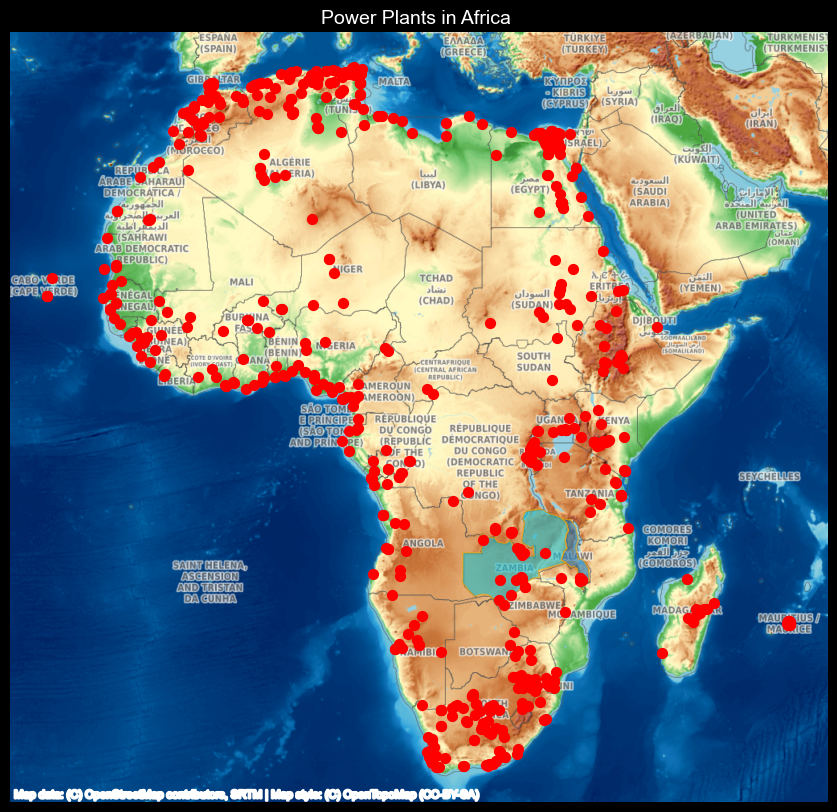

In [15]:
import contextily as cx
# Create a figure
fig, ax = plt.subplots(figsize=(12, 10))

# Plot our data (must be in Web Mercator projection for contextily)
power_plants_web = power_plants_gdf.to_crs(epsg=3857)  # Convert to Web Mercator
power_plants_web.plot(ax=ax, marker='o', color='red', markersize=50, zorder=5)

# Add african boundaries
countries_web = countries.to_crs(epsg=3857)

# --- Three-layer example with transparency ---
# Layer 1 - base fill with transparency (alpha)
# countries_web.plot(ax=ax, color='lightgray', edgecolor='none', alpha=0.4, zorder=1)

# Layer 2 - optional highlight for a couple of countries (example: Zambia & Malawi)
# Note: the GeoDataFrame is expected to have a 'name_long' column (used elsewhere in the notebook)

highlight_countries = countries_web[countries_web.get('name_long', pd.Series()).isin(['Zambia', 'Malawi'])]
highlight_countries.plot(ax=ax, column='name_long', edgecolor='orange', alpha=0.6, zorder=4)

# Layer 3 - country boundaries on top with higher opacity
# countries_web.boundary.plot(ax=ax, linewidth=0.6, edgecolor='black', alpha=0.8, zorder=3)

# Add the basemap AFTER plotting data
cx.add_basemap(ax, source=cx.providers.OpenTopoMap)

ax.set_title('Power Plants in Africa ', fontsize=14)
ax.set_axis_off()  # Hide the axis numbers
plt.show()

In [ ]:
cx.providers

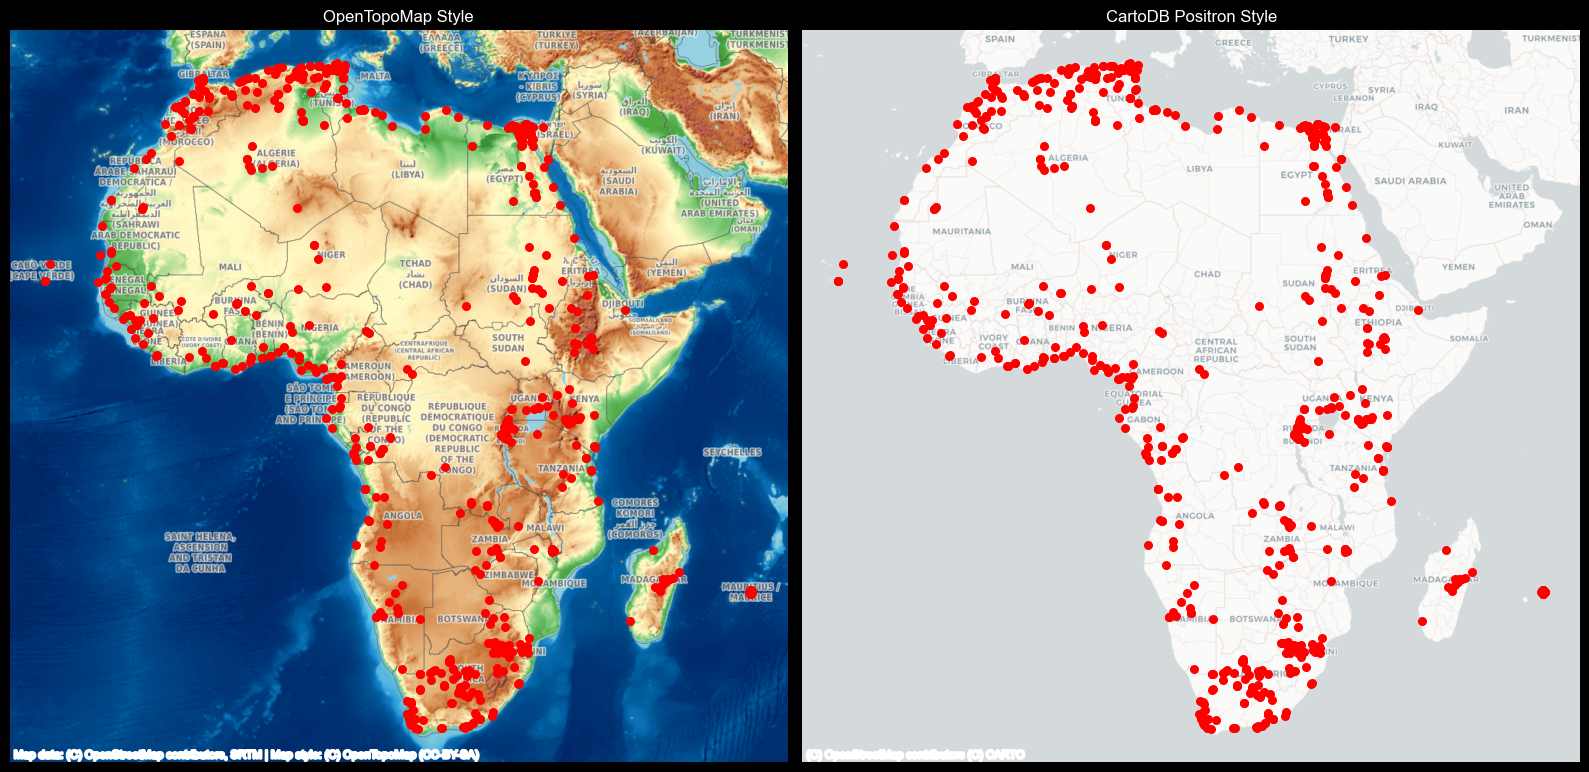

In [16]:
# Compare two styles side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Style 1: OpenTopoMap (terrain)
power_plants_web.plot(ax=axes[0], color='red', markersize=30)
cx.add_basemap(axes[0], source=cx.providers.OpenTopoMap)
axes[0].set_title('OpenTopoMap Style')
axes[0].set_axis_off()

# Style 2: CartoDB Positron (clean for reports)
power_plants_web.plot(ax=axes[1], color='red', markersize=30)
cx.add_basemap(axes[1], source=cx.providers.CartoDB.Positron)
axes[1].set_title('CartoDB Positron Style')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

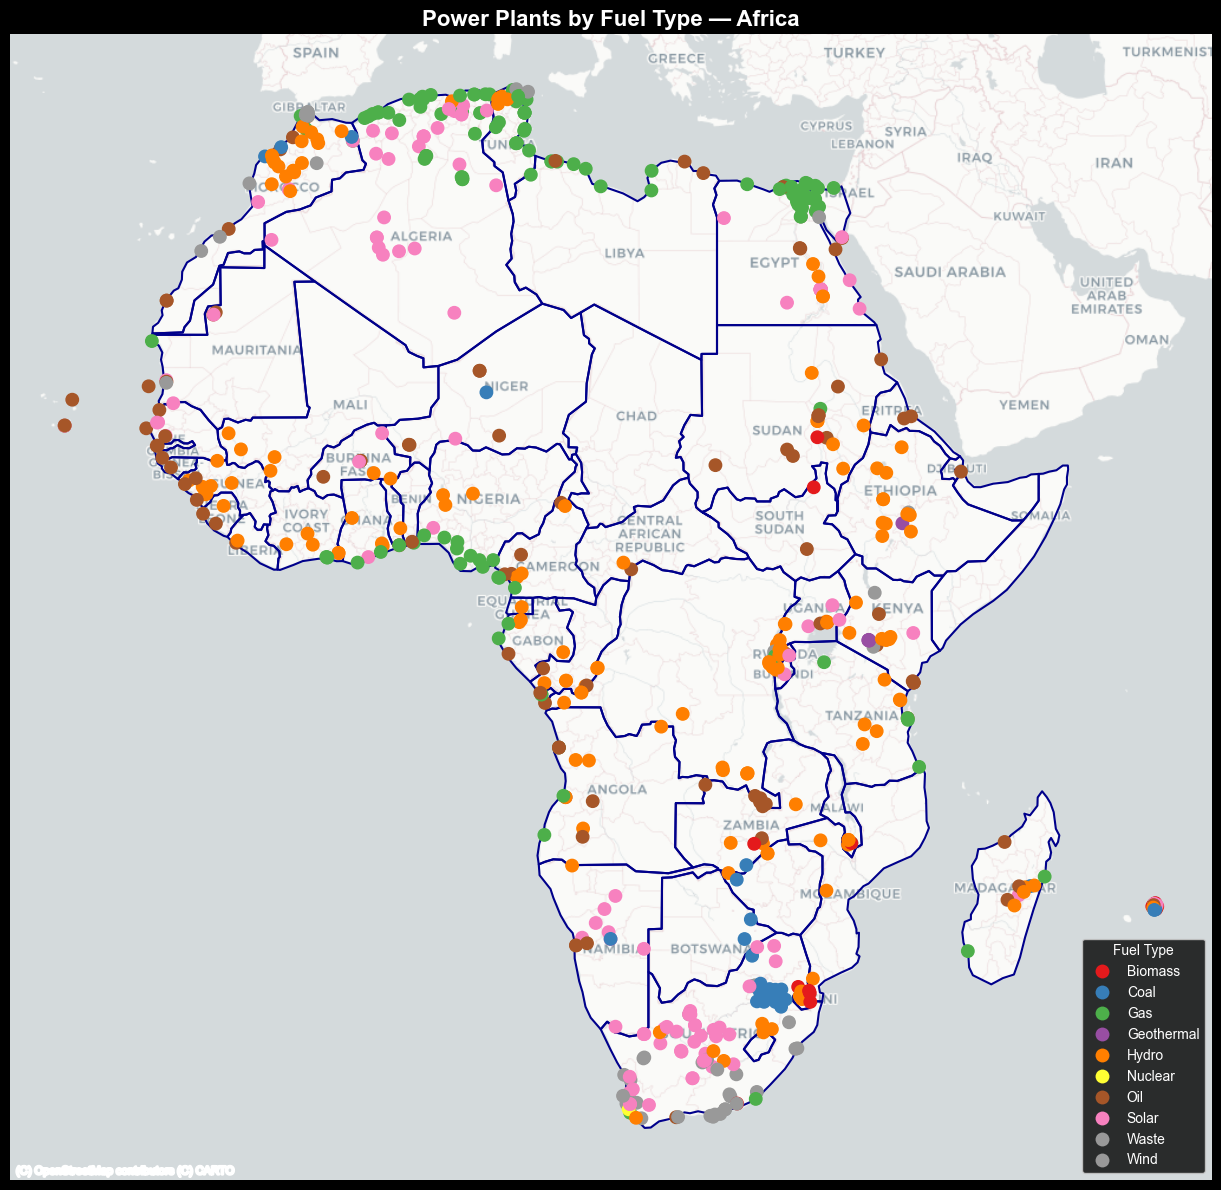

In [17]:
# Load country boundaries (same as Lessons 7.1 and 7.2)

fig, ax = plt.subplots(figsize=(14, 12))

# Project all data to Web Mercator
countries_web = countries.to_crs(epsg=3857)
power_plants_web = power_plants_gdf.to_crs(epsg=3857)

# LAYER 2 (middle): Country boundaries
countries_web.plot(
    ax=ax,
    facecolor='none',        # Transparent fill
    edgecolor='darkblue',    # Blue boundary lines
    linewidth=1.5,
    zorder=2                 # Drawing order
)

# LAYER 3 (top): Power plants colored by fuel type
power_plants_web.plot(
    ax=ax,
    column='primary_fuel',   # Color by fuel type
    cmap='Set1',
    markersize=80,
    legend=True,
    legend_kwds={'title': 'Fuel Type', 'loc': 'lower right'},
    zorder=3                 # On top of boundaries
)

# LAYER 1 (bottom): Basemap — added last but drawn at the bottom
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zorder=1)

ax.set_title('Power Plants by Fuel Type — Africa', fontsize=16, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

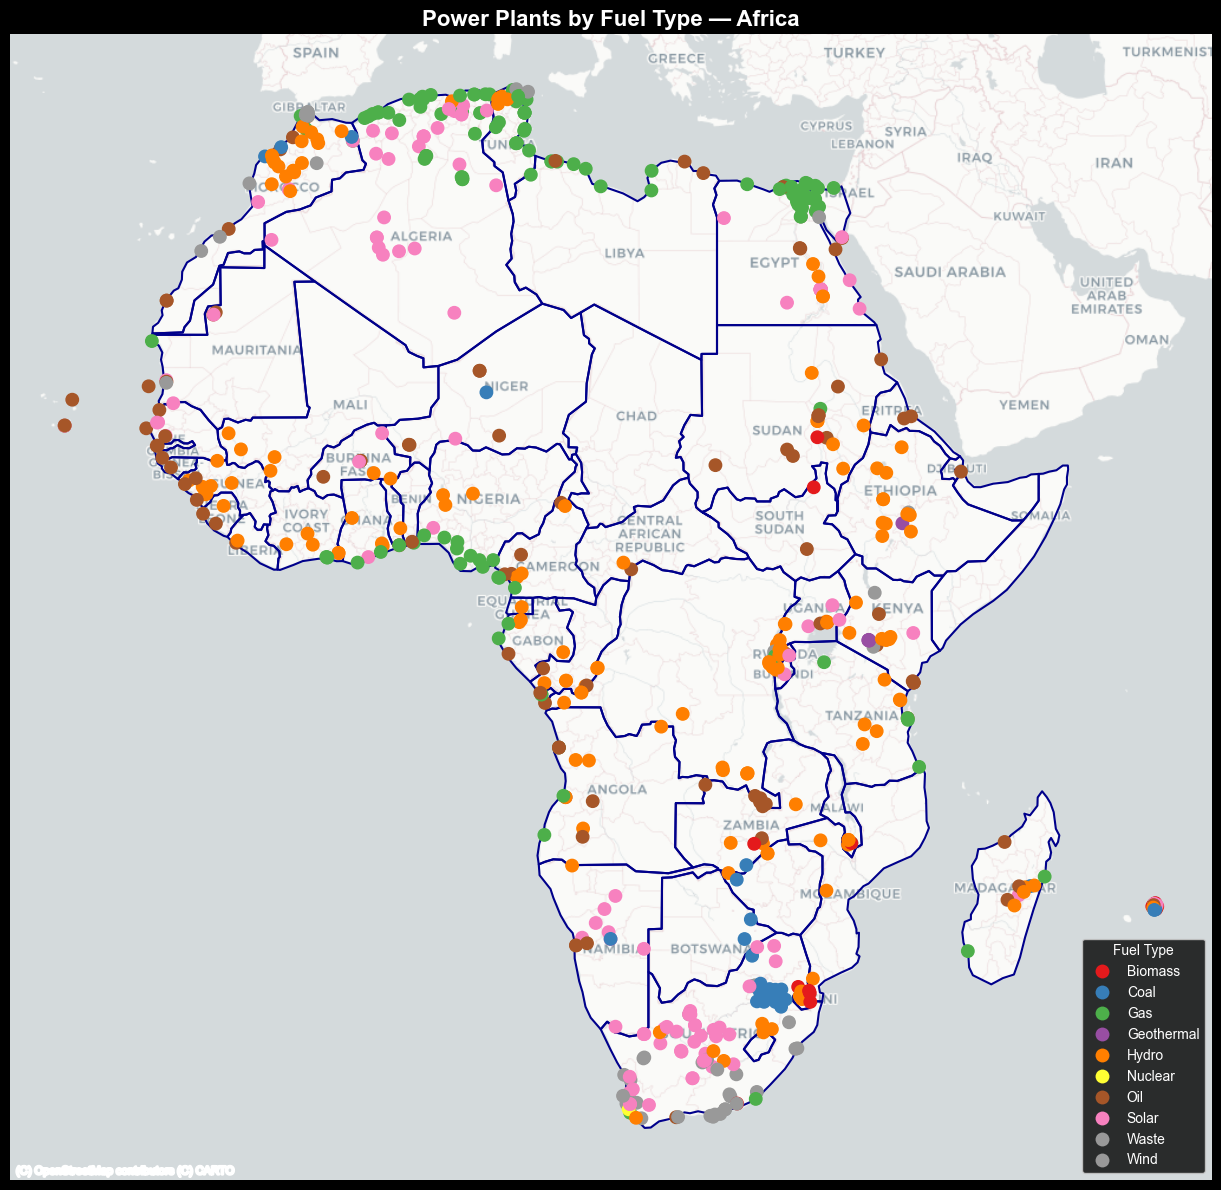

In [18]:
# Load country boundaries (same as Lessons 7.1 and 7.2)

fig, ax = plt.subplots(figsize=(14, 12))

# Project all data to Web Mercator
countries_web = countries.to_crs(epsg=3857)
power_plants_web = power_plants_gdf.to_crs(epsg=3857)

# LAYER 1 (top): Power plants coloured by fuel type
power_plants_web.plot(
    ax=ax,
    column='primary_fuel',   # Color by fuel type
    cmap='Set1',
    markersize=80,
    legend=True,
    legend_kwds={'title': 'Fuel Type', 'loc': 'lower right'},
    zorder=3
)

# LAYER 2 (bottom): Country boundaries
countries_web.plot(
    ax=ax,
    facecolor='none',        # Transparent fill
    edgecolor='darkblue',    # Blue boundary lines
    linewidth=1.5,
    zorder=2
)

# LAYER 3 (basemap): Added last — contextily draws it behind everything
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_title('Power Plants by Fuel Type — Africa', fontsize=16, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()